In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
dataset=pd.read_csv('origination_data-2.csv')

In [3]:
dataset.head()

,customer_id,application_date,age,gender,employment_status,annual_income,monthly_income,loan_amount,interest_rate,loan_term,emi,dti,credit_score_origination,revolving_utilization_origination,credit_inquiries_12m,deterioration_pattern,default_12m,vintage_year,vintage_month
0,CUST100000,2022-04-08,42,Male,Self-Employed,83834.0,6986.17,50000.0,12.33,36,1668.61,0.35,720,0.433,0,stable,0,2022,2022-04
1,CUST100001,2024-04-28,35,Female,Employed,56472.0,4706.00,50000.0,10.98,48,1291.79,0.41,658,0.250,1,gradual_decline,0,2024,2024-04
2,CUST100002,2023-12-19,44,Male,Employed,165696.0,13808.00,50000.0,9.71,84,822.59,0.44,801,0.339,2,stable,0,2023,2023-12
3,CUST100003,2023-04-27,41,Female,Employed,79943.0,6661.92,50000.0,14.42,36,1719.10,0.38,743,0.617,0,gradual_decline,0,2023,2023-04
4,CUST100004,2023-04-20,28,Female,Employed,160442.0,13370.17,52071.0,10.81,36,1700.06,0.10,662,0.215,1,stable,0,2023,2023-04


In [4]:
dataset.shape

(135000, 19)

In [5]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135000 entries, 0 to 134999
Data columns (total 19 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   customer_id                        135000 non-null  object 
 1   application_date                   135000 non-null  object 
 2   age                                135000 non-null  int64  
 3   gender                             135000 non-null  object 
 4   employment_status                  135000 non-null  object 
 5   annual_income                      135000 non-null  float64
 6   monthly_income                     135000 non-null  float64
 7   loan_amount                        135000 non-null  float64
 8   interest_rate                      135000 non-null  float64
 9   loan_term                          135000 non-null  int64  
 10  emi                                135000 non-null  float64
 11  dti                                1350

In [6]:
dataset.describe()

,age,annual_income,monthly_income,loan_amount,interest_rate,loan_term,emi,dti,credit_score_origination,revolving_utilization_origination,credit_inquiries_12m,default_12m,vintage_year
count,135000.000000,1.350000e+05,135000.000000,135000.000000,135000.000000,135000.000000,135000.000000,135000.000000,135000.000000,135000.000000,135000.000000,135000.000000,135000.000000
mean,35.056563,1.269146e+05,10576.219728,53847.406556,12.009857,56.648711,1323.960613,0.311609,690.070074,0.285185,1.992067,0.076807,2023.002659
std,7.447288,7.544586e+04,6287.155025,13575.098843,2.057163,14.897064,446.220126,0.107145,50.160643,0.159700,1.397608,0.266287,0.817307
min,20.000000,7.670000e+03,639.170000,50000.000000,7.000000,36.000000,754.630000,0.100000,463.000000,0.001000,0.000000,0.000000,2022.000000
25%,30.000000,7.546850e+04,6289.040000,50000.000000,10.610000,48.000000,1056.460000,0.240000,656.000000,0.161000,1.000000,0.000000,2022.000000
50%,35.000000,1.091670e+05,9097.250000,50000.000000,12.010000,60.000000,1190.810000,0.310000,690.000000,0.264000,2.000000,0.000000,2023.000000
75%,40.000000,1.579502e+05,13162.520000,50000.000000,13.400000,60.000000,1598.840000,0.380000,724.000000,0.388000,3.000000,0.000000,2024.000000
max,64.000000,1.238352e+06,103196.000000,423686.000000,21.210000,84.000000,13047.780000,0.700000,900.000000,0.941000,6.000000,1.000000,2024.000000


In [7]:
dataset.isnull().sum()

customer_id                          0
application_date                     0
age                                  0
gender                               0
employment_status                    0
annual_income                        0
monthly_income                       0
loan_amount                          0
interest_rate                        0
loan_term                            0
emi                                  0
dti                                  0
credit_score_origination             0
revolving_utilization_origination    0
credit_inquiries_12m                 0
deterioration_pattern                0
default_12m                          0
vintage_year                         0
vintage_month                        0
dtype: int64

In [8]:
dataset=dataset.drop_duplicates()

In [9]:
dataset.shape

(135000, 19)

In [10]:
# Filter out any negative values generated by normal distribution
dataset['annual_income'] = dataset['annual_income'].abs()
dataset['loan_amount'] = dataset['loan_amount'].abs()

### Feature Extractions 

In [11]:
# Calculate dependent columns
dataset['monthly_income'] = dataset['annual_income'] / 12
dataset['emi'] = (dataset['loan_amount'] * (1 + dataset['interest_rate']/100)) / dataset['loan_term'] 
dataset['dti'] = dataset['emi'] / dataset['monthly_income']

In [12]:
dataset['utilization_to_inquiries'] = dataset['revolving_utilization_origination'] * dataset['credit_inquiries_12m']

In [13]:
dataset['is_subprime'] = (dataset['credit_score_origination'] < 600).astype(int)

In [14]:
# Assuming a DTI over 40% (0.40) is considered high risk
dataset['subprime_high_dti'] = dataset['is_subprime'] * (dataset['dti'] > 0.40).astype(int)

# You can also do the same for high EMI relative to income
dataset['subprime_high_emi'] = dataset['is_subprime'] * (dataset['emi'] > (dataset['monthly_income'] * 0.30)).astype(int)

In [15]:
# Drop ONLY the old features. Do NOT drop 'emi' and 'dti'.
dataset = dataset.drop(['annual_income', 'loan_amount', 'interest_rate', 'loan_term' ,'revolving_utilization_origination','credit_inquiries_12m'
                       , 'is_subprime' ,'dti' ,'emi' ,'monthly_income'], axis=1)

In [16]:
numerical_features = [
    'age', 'subprime_high_dti' , 'subprime_high_emi', 
     'utilization_to_inquiries', 
]

categorical_features = [
    'gender', 'employment_status', 'deterioration_pattern', 
     'vintage_year', 'vintage_month'
]

### Data Visualization 

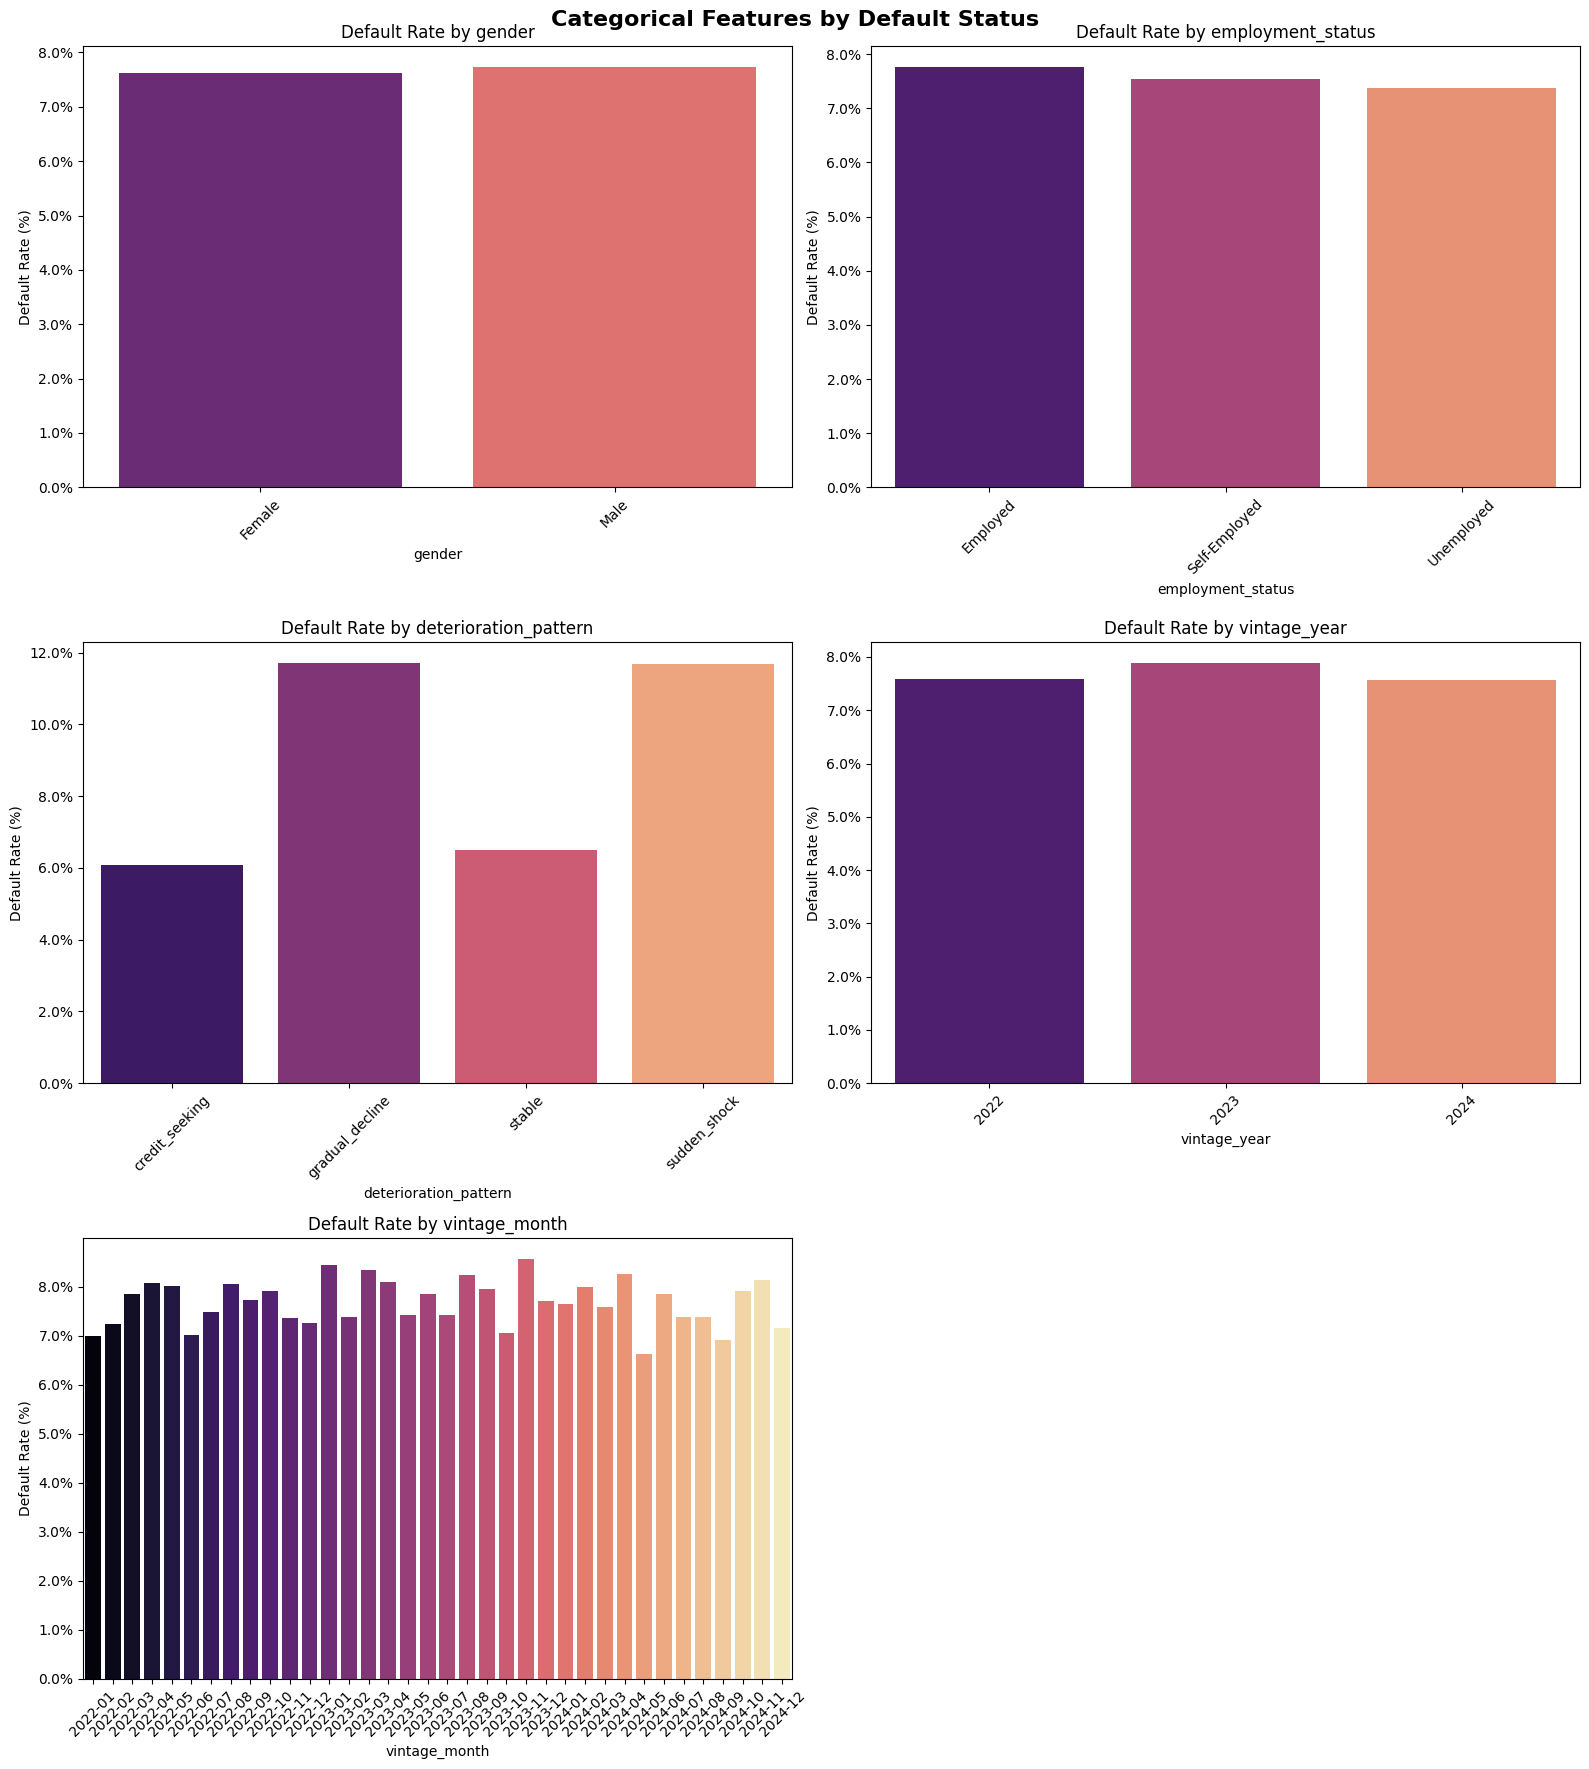

In [17]:
# ==========================================
# 2. CATEGORICAL FEATURES VISUALIZATION
# ==========================================
# Filter to only the columns that actually exist
valid_cat = [col for col in categorical_features if col in dataset.columns]

if not valid_cat:
    print("WARNING: None of your categorical features exist in this dataset.")
else:
    cat_rows = int(np.ceil(len(valid_cat) / 2))
    fig, axes = plt.subplots(cat_rows, 2, figsize=(16, 6 * cat_rows))
    fig.suptitle('Categorical Features by Default Status', fontsize=16, fontweight='bold', y=0.98)
    axes = axes.flatten()

    for i, col in enumerate(valid_cat):
        # We must normalize the counts, otherwise the 92% majority class will crush the minority class visually
        props = dataset.groupby(col)["default_12m"].value_counts(normalize=True).unstack()
        
        # Plotting the percentage of defaults per category
        if 1 in props.columns: # Check if class '1' exists
            sns.barplot(x=props.index, y=props[1], ax=axes[i], palette='magma')
            axes[i].set_title(f'Default Rate by {col}', fontsize=12)
            axes[i].set_ylabel('Default Rate (%)', fontsize=10)
            axes[i].tick_params(axis='x', rotation=45)
            # Format y-axis as percentage
            import matplotlib.ticker as mtick
            axes[i].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
        else:
            axes[i].text(0.5, 0.5, 'No Default Data', ha='center', va='center')

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
        
    plt.tight_layout()
    plt.show()

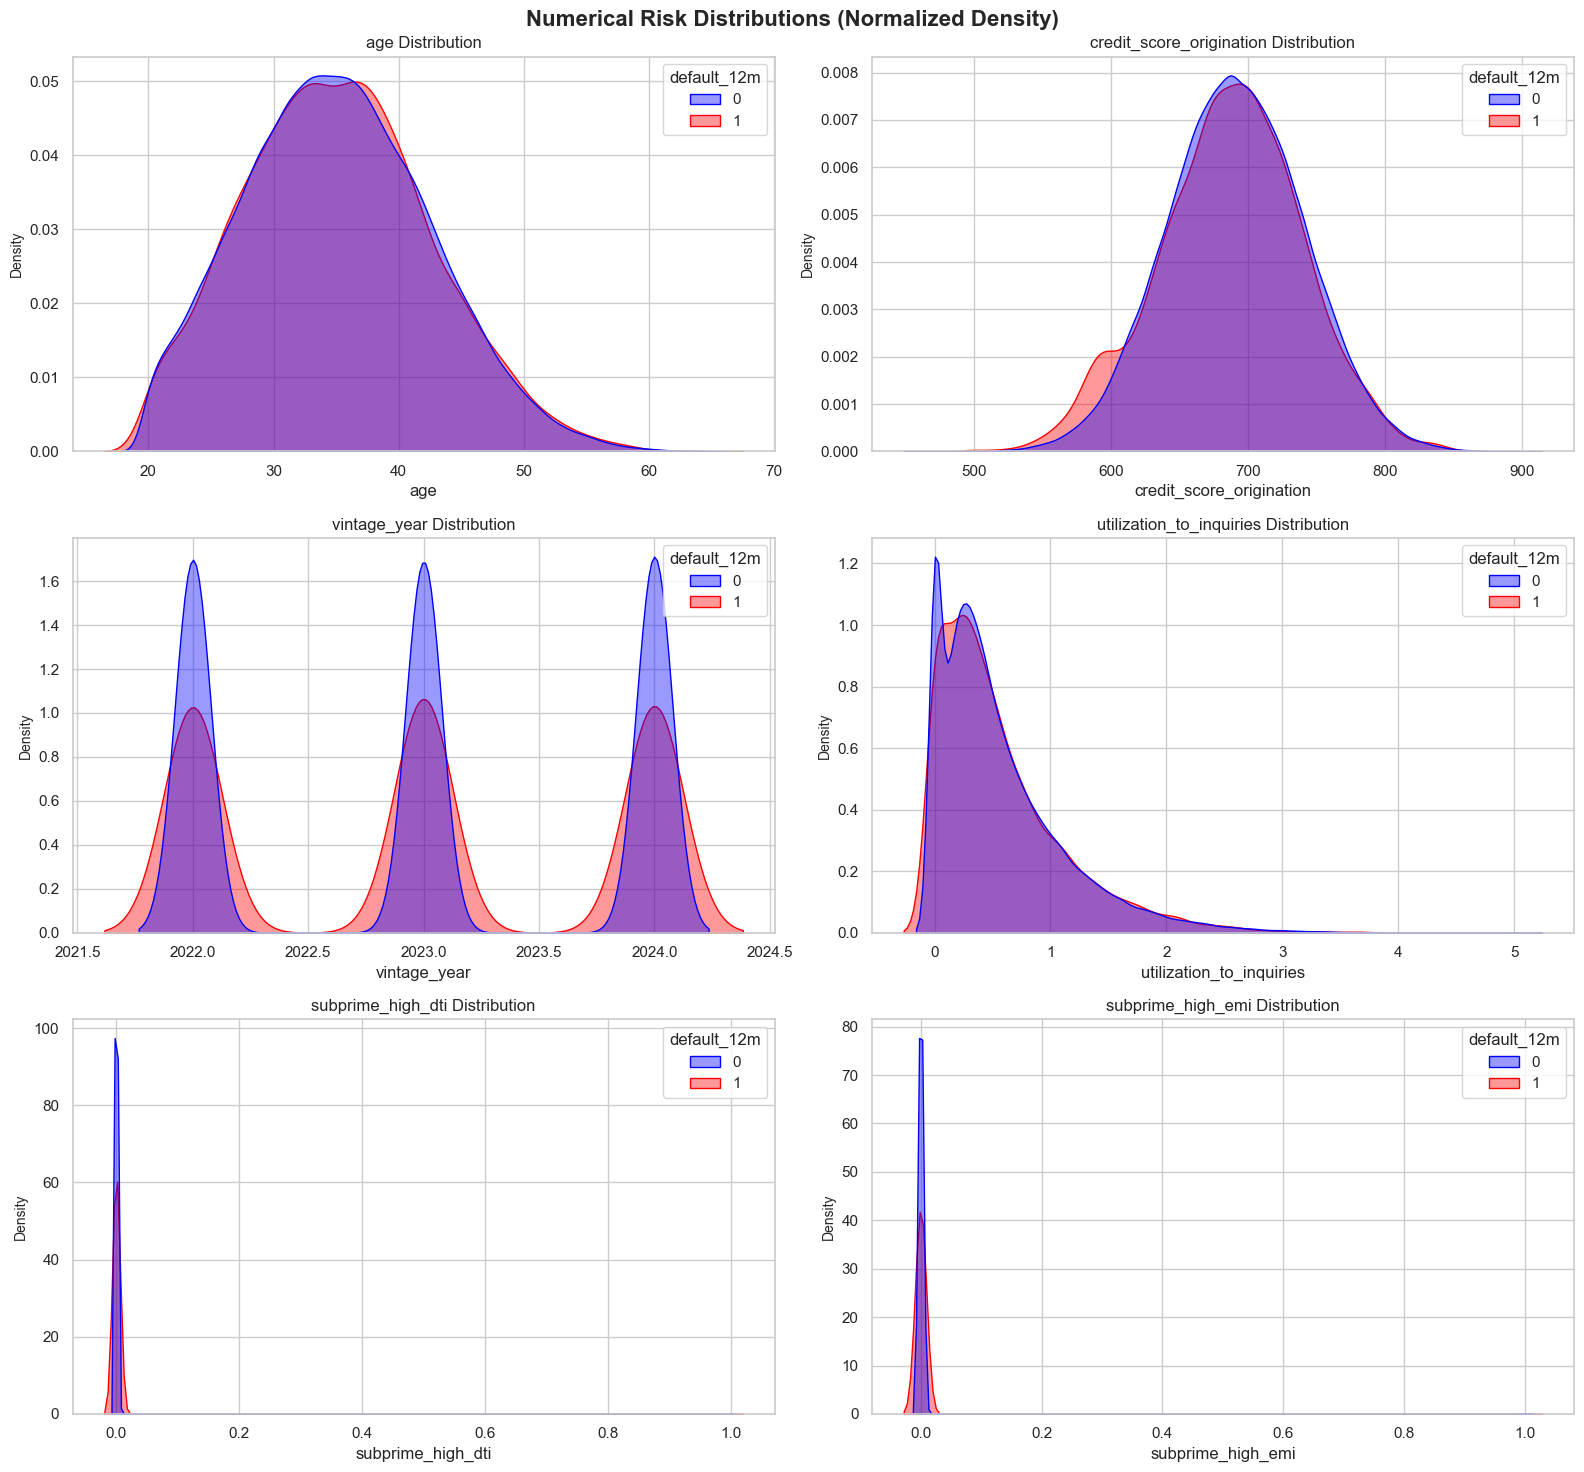

KeyboardInterrupt: 

Error in callback <function _draw_all_if_interactive at 0x00000198A54218A0> (for post_execute), with arguments args (),kwargs {}:



KeyboardInterrupt



Error in callback <function flush_figures at 0x00000198B67DB600> (for post_execute), with arguments args (),kwargs {}:



KeyboardInterrupt



In [18]:
# Set the target column based on your previous output
target_col = 'default_12m'

# 1. Dynamically identify feature types (excluding the target itself)
features = dataset.drop(columns=[target_col])
numerical_cols = features.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = features.select_dtypes(include=['object', 'category']).columns.tolist()

# Set style
sns.set_theme(style="whitegrid")

# ==========================================
# 2. NUMERICAL FEATURES (Density Plots)
# ==========================================
# We will plot up to the first 6 numerical features to avoid crashing your kernel
num_to_plot = numerical_cols[:6]

if num_to_plot:
    num_rows = int(np.ceil(len(num_to_plot) / 2))
    fig, axes = plt.subplots(num_rows, 2, figsize=(16, 5 * num_rows))
    fig.suptitle('Numerical Risk Distributions (Normalized Density)', fontsize=16, fontweight='bold', y=0.98)
    axes = axes.flatten()

    for i, col in enumerate(num_to_plot):
        # common_norm=False is CRITICAL here. It lets us see the minority class shape.
        sns.kdeplot(data=dataset, x=col, hue=target_col, fill=True, common_norm=False, 
                    palette={0: 'blue', 1: 'red'}, alpha=0.4, ax=axes[i])
        axes[i].set_title(f'{col} Distribution', fontsize=12)
        axes[i].set_ylabel('Density', fontsize=10)

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
        
    plt.tight_layout()
    plt.show()

# ==========================================
# 3. CATEGORICAL FEATURES (Default Rates)
# ==========================================
# Plot up to the first 6 categorical features
cat_to_plot = categorical_cols[:6]

if cat_to_plot:
    cat_rows = int(np.ceil(len(cat_to_plot) / 2))
    fig, axes = plt.subplots(cat_rows, 2, figsize=(16, 5 * cat_rows))
    fig.suptitle('Categorical Risk: Default Rate per Category', fontsize=16, fontweight='bold', y=0.98)
    axes = axes.flatten()

    for i, col in enumerate(cat_to_plot):
        # Calculate the actual default percentage for each category
        default_rates = dataset.groupby(col, observed=False)[target_col].mean().sort_values(ascending=False).reset_index()
        
        sns.barplot(data=default_rates, x=col, y=target_col, ax=axes[i], palette='Reds_r')
        axes[i].set_title(f'Default Rate by {col}', fontsize=12)
        axes[i].set_ylabel('Default Rate', fontsize=10)
        axes[i].tick_params(axis='x', rotation=45)
        axes[i].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
        
    plt.tight_layout()
    plt.show()

# ==========================================
# 4. THE REALITY CHECK: Target Correlation
# ==========================================
print("\n=== TOP LINEAR RISK FACTORS ===")
# Correlate all numerical columns directly against the target and sort them
target_corr = dataset[numerical_cols + [target_col]].corr()[target_col].drop(target_col)
print(target_corr.sort_values(ascending=False, key=abs).head(10))

In [19]:
print(dataset[numerical_cols].info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135000 entries, 0 to 134999
Data columns (total 6 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   age                       135000 non-null  int64  
 1   credit_score_origination  135000 non-null  int64  
 2   vintage_year              135000 non-null  int64  
 3   utilization_to_inquiries  135000 non-null  float64
 4   subprime_high_dti         135000 non-null  int64  
 5   subprime_high_emi         135000 non-null  int64  
dtypes: float64(1), int64(5)
memory usage: 6.2 MB
None


In [20]:
corr_matrix = dataset[numerical_cols].corr()
print(corr_matrix)

                               age  credit_score_origination  vintage_year  \
age                       1.000000                  0.000383      0.005441   
credit_score_origination  0.000383                  1.000000     -0.000800   
vintage_year              0.005441                 -0.000800      1.000000   
utilization_to_inquiries -0.000862                 -0.000155     -0.000434   
subprime_high_dti        -0.000677                 -0.060402      0.003830   
subprime_high_emi        -0.001149                 -0.102070      0.003189   

                          utilization_to_inquiries  subprime_high_dti  \
age                                      -0.000862          -0.000677   
credit_score_origination                 -0.000155          -0.060402   
vintage_year                             -0.000434           0.003830   
utilization_to_inquiries                  1.000000           0.005222   
subprime_high_dti                         0.005222           1.000000   
subprime_high_e

### Model Creations 

In [21]:
from sklearn.model_selection import train_test_split , RandomizedSearchCV
from sklearn.preprocessing import StandardScaler  , OneHotEncoder
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier , AdaBoostClassifier , GradientBoostingClassifier 
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score , classification_report ,precision_recall_curve

In [22]:
numerical_features = [
    'age', 'subprime_high_dti' , 'subprime_high_emi', 
     'utilization_to_inquiries', 
]

categorical_features = [
    'gender', 'employment_status', 'deterioration_pattern', 
     'vintage_year', 'vintage_month'
]

In [23]:
dataset.head()

,customer_id,application_date,age,gender,employment_status,credit_score_origination,deterioration_pattern,default_12m,vintage_year,vintage_month,utilization_to_inquiries,subprime_high_dti,subprime_high_emi
0,CUST100000,2022-04-08,42,Male,Self-Employed,720,stable,0,2022,2022-04,0.000,0,0
1,CUST100001,2024-04-28,35,Female,Employed,658,gradual_decline,0,2024,2024-04,0.250,0,0
2,CUST100002,2023-12-19,44,Male,Employed,801,stable,0,2023,2023-12,0.678,0,0
3,CUST100003,2023-04-27,41,Female,Employed,743,gradual_decline,0,2023,2023-04,0.000,0,0
4,CUST100004,2023-04-20,28,Female,Employed,662,stable,0,2023,2023-04,0.215,0,0


In [24]:
dataset['subprime_high_emi'].unique()

array([0, 1])

In [25]:
numeric_transformer = ImbPipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = ImbPipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first')) # drop='first' helps prevent multicollinearity
])



In [26]:
# 3. Combine them into the ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [27]:
X=dataset.drop(['default_12m','customer_id'] , axis=1)
y=dataset['default_12m']

In [28]:
 X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Random Forest Classifier

In [48]:
Rnf_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
     ("sm",SMOTE()),
    ('model', RandomForestClassifier(n_jobs=100 , class_weight="balanced"))
])

In [49]:
Rnf_pipeline.fit(X_train,y_train)

,steps,"[('preprocessor', ...), ('sm', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [50]:
Rnf_prob = Rnf_pipeline.predict_proba(X_test)[:, 1] # Get probabilities for Class 1
custom_threshold = 0.35
Rnf_pred = (Rnf_prob >= custom_threshold).astype(int)

# Check the new accuracy score
accuracy_score(y_test, Ada_pred) * 100

73.54444444444445

In [51]:
print(classification_report(y_test,Ada_pred))

              precision    recall  f1-score   support

           0       0.92      0.78      0.84     24927
           1       0.07      0.22      0.11      2073

    accuracy                           0.74     27000
   macro avg       0.50      0.50      0.48     27000
weighted avg       0.86      0.74      0.79     27000



### Logistic Regressions

In [33]:
Lr = ImbPipeline(
    [
       ('preprocessor', preprocessor),
        ('sm',SMOTE()),
       ('classifier', LogisticRegression(class_weight='balanced')) 
    ]
)

In [34]:
Lr.fit(X_train,y_train)

,steps,"[('preprocessor', ...), ('sm', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [35]:
lr_pred=Lr.predict(X_test)

In [36]:
accuracy_score(y_test,lr_pred)

0.6984444444444444

In [37]:
print(classification_report(y_test,lr_pred))

              precision    recall  f1-score   support

           0       0.94      0.72      0.82     24927
           1       0.11      0.40      0.17      2073

    accuracy                           0.70     27000
   macro avg       0.52      0.56      0.49     27000
weighted avg       0.87      0.70      0.77     27000



In [38]:
# We slice [:, 1] to get the probability of Class 1 (Default)
y_probs = Lr.predict_proba(X_test)[:, 1]

# 2. Calculate Precision and Recall across ALL possible thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)

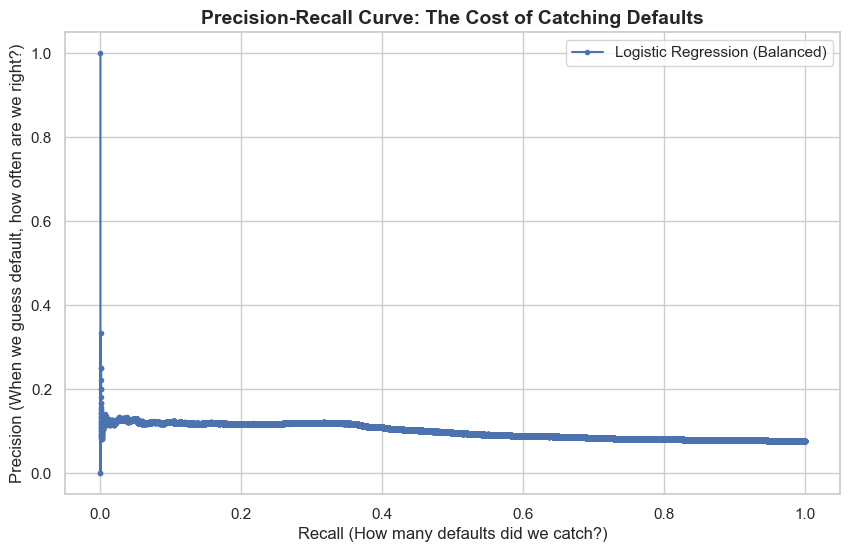

In [39]:
# 3. Plot the unforgiving reality of your model
plt.figure(figsize=(10, 6))
plt.plot(recall, precision, marker='.', label='Logistic Regression (Balanced)')
plt.title('Precision-Recall Curve: The Cost of Catching Defaults', fontsize=14, fontweight='bold')
plt.xlabel('Recall (How many defaults did we catch?)', fontsize=12)
plt.ylabel('Precision (When we guess default, how often are we right?)', fontsize=12)
plt.grid(True)
plt.legend()
plt.show()

### Decision Tree Classifier

In [40]:
tree_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
     ("sm",SMOTE()),
    ('model', DecisionTreeClassifier(random_state=42))
])

In [41]:
tree_pipeline.fit(X_train,y_train)

,steps,"[('preprocessor', ...), ('sm', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [42]:
tree_predict=tree_pipeline.predict(X_test)

In [43]:
print(classification_report(y_test,tree_predict))

              precision    recall  f1-score   support

           0       0.92      0.90      0.91     24927
           1       0.08      0.11      0.10      2073

    accuracy                           0.84     27000
   macro avg       0.50      0.51      0.50     27000
weighted avg       0.86      0.84      0.85     27000



### Ada Boosting Classifier

In [44]:
Ada_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
     ("sm",SMOTE()),
    ('model', AdaBoostClassifier(random_state=42))
])

In [45]:
Ada_pipeline.fit(X_train,y_train)

,steps,"[('preprocessor', ...), ('sm', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [46]:
ada_prob = Ada_pipeline.predict_proba(X_test)[:, 1] # Get probabilities for Class 1
custom_threshold = 0.4
Ada_pred = (ada_prob >= custom_threshold).astype(int)

# Check the new accuracy score
accuracy_score(y_test, Ada_pred) * 100

18.76666666666667

In [47]:
print(classification_report(y_test,Ada_pred))

              precision    recall  f1-score   support

           0       0.93      0.13      0.23     24927
           1       0.08      0.89      0.14      2073

    accuracy                           0.19     27000
   macro avg       0.50      0.51      0.19     27000
weighted avg       0.87      0.19      0.22     27000

